In [2]:
import sys, os
current_dir = os.getcwd()
project_root = current_dir[:current_dir.find("src") - 1]
sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.models.train_model.train_model import *

In [3]:
from lightgbm import LGBMRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split
import numpy as np

In [4]:
def train_model(df_train, model_X_cols, n_mimo, param,save_model=False, save_model_folder=None):
    feature_selector = Feature_selector(df_train, target="generation")
    Xs_train, ys_train, name_code_df = feature_selector.get_X_and_y(n_mimo=n_mimo)
    Xs_train = Xs_train.reindex(columns=model_X_cols)
    Xs_train = Xs_train.fillna(False).infer_objects()

    # تعریف مدل AdaBoostRegressor با مدل پایه و تعداد استیمیتورها
    #model = MultiOutputRegressor(LGBMRegressor(learning_rate=param["learning_rate"], n_estimators=param["n_est"],verbose=-1))

    model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=param["n_est"], max_depth=param["m_depth"], learning_rate=0.1)
    # model = RandomForestRegressor(n_estimators=param["n_est"], max_depth=param["m_depth"], random_state=42)
    model.fit(Xs_train, ys_train)
    logger.info(f"Model has been trained successfully")

    ys_pred = model.predict(Xs_train)

    y_pred = get_y_inverse_mimo(df_train, feature_selector, name_code_df, n_mimo, ys_pred)
    y_train = get_y_inverse_mimo(df_train, feature_selector, name_code_df, n_mimo, ys_train)

    rmse_error_train = compute_relative_rmse(y_pred, y_train)
    thresh_error_train = compute_threshold_error(y_pred, y_train)
    rmae_error = compute_relative_mae(y_pred, y_train)
    r2_score = compute_r2_score(y_pred, y_train)
    #logger.info(f"Train rmse error: {rmse_error_train:0.3f}%")
    #logger.info(f"Train threshold error: {thresh_error_train:0.3f}%")
    #logger.info(f"Train rmae error: {rmae_error:0.3f}%")
    #logger.info(f"R2 score: {r2_score:0.3f}%")
    return model,(rmse_error_train,thresh_error_train,rmae_error,r2_score)
    if save_model and save_model_folder is not None:
        for filename in os.listdir(save_model_folder):
            os.remove(os.path.join(save_model_folder, filename))

        dump(model, f"{save_model_folder}/model.joblib")
        with open(f"{save_model_folder}/model_cols.pkl", 'wb') as f:
            dump(model_X_cols, f)

In [5]:
def test_model(model, df_test, model_X_cols, n_mimo):
    feature_selector = Feature_selector(df_test, target="generation")
    Xs_test, ys_test, name_code_df = feature_selector.get_X_and_y(n_mimo=n_mimo)
    Xs_test = Xs_test.reindex(columns=model_X_cols)
    Xs_test = Xs_test.fillna(False).infer_objects()

    ys_pred = model.predict(Xs_test)
    y_pred = get_y_inverse_mimo(df_test, feature_selector, name_code_df, n_mimo, ys_pred)
    y_test = get_y_inverse_mimo(df_test, feature_selector, name_code_df, n_mimo, ys_test)

    rmse_error_test = compute_relative_rmse(y_pred, y_test)
    thresh_error_test = compute_threshold_error(y_pred, y_test)
    rmae_error = compute_relative_mae(y_pred, y_test)
    r2_score = compute_r2_score(y_pred, y_test)
    return (rmse_error_test,thresh_error_test,rmae_error,r2_score),y_pred,y_test
 
    logger.info(f"Test rmse error: {rmse_error_test:0.3f}%")
    logger.info(f"Test threshold error: {thresh_error_test:0.3f}%")
    logger.info(f"Test rmae error: {rmae_error:0.3f}%")
    logger.info(f"R2 score: {r2_score:0.3f}%")

In [8]:
csv_semi_processed_path = os.path.join(project_root, "data", "processed", "semi_processed.csv")
df = pd.read_csv(csv_semi_processed_path, encoding='utf-8')

add_is_test_column(df, random_state=42)

save_model = True
save_model_folder = os.path.join(project_root, "src", "models", "fitted_models")

df_r_selected = Data_selector(df).select_peaks(goodness=3)

base_features = ["name", "code", "temperature", "humidity", "dew", "surface_pressure","evapotransporation","snow","rain",
                 "wind_speed","wind_direction","apparent_temperature","precipitation"]
features_with_lag = ["temperature", "humidity", "dew", "surface_pressure"]
hours_delay = [1, 5]
lag_features = [f"{feature}_with_{hour}_delay" for feature in features_with_lag for hour in hours_delay]
# lag_features.append("generation_with_24_delay")
time_features = ["hour", "day_of_week", "month", "season", "datetime"]
df_f_selected = select_dataset_features(df_r_selected, base_features, lag_features, time_features, "generation")

2025-09-30 15:30:25 - train_model - INFO - Some features have been dropped successfully


In [ ]:
n_mimo = 4
model_X_cols = find_after_mimo_cols(df_f_selected, n_mimo)

train_indices = (df_r_selected['is_test'] == False)
train_df = df_f_selected[train_indices]
param = {"n_est":3000,"m_depth":7,"learning_rate":0.1}
model,e = train_model(train_df, model_X_cols, n_mimo,param=param, save_model=save_model, save_model_folder=save_model_folder)
test_indices = (df_r_selected['is_test'] == True)
test_df = df_f_selected[test_indices]

In [ ]:
e,y_pred,y_test = test_model(model, test_df, model_X_cols, n_mimo)

In [ ]:
e

(2.3997650351224245, 49.13845642417862, 1.5253053723117014, 0.9926914654996234)

In [9]:
r = (y_pred-y_test)/y_test

In [10]:
print(f"r.mean():{r.mean()}")
print(f"mse:{(r**2).mean()}")
print(f"rmse:{(r**2).mean()}**0.5")


r.mean():0.0005075750993192891
mse:0.0004958993408046261
rmse:0.0004958993408046261**0.5


In [17]:
(r).max()

0.17775815277181733

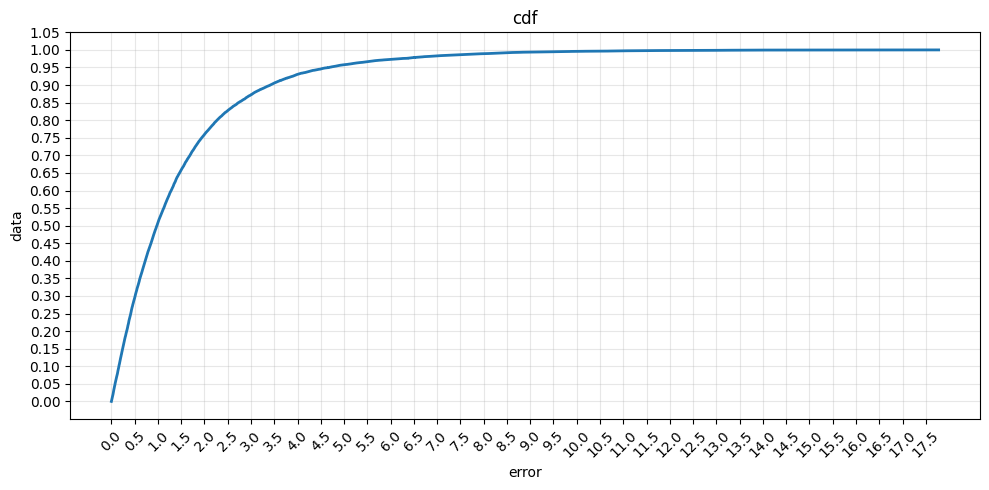

In [32]:
rr = np.abs(r)*100
data = rr
sorted_data = np.sort(data)
y = np.linspace(0, 1, len(sorted_data))
plt.figure(figsize=(10,5))
plt.plot(sorted_data, y, linewidth=2)

# تنظیم محورها با دقت ۰.۱
x_min, x_max = np.min(data), np.max(data)
x_ticks = np.arange(np.floor(x_min), np.ceil(x_max), 0.5)
y_ticks = np.arange(0, 1.1, 0.05)

plt.xticks(x_ticks, rotation=45)
plt.yticks(y_ticks)
plt.xlabel('error')
plt.ylabel('data')
plt.title('cdf')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

1.0

(array([6.123e+03, 4.168e+03, 2.690e+03, 1.679e+03, 1.033e+03, 7.130e+02,
        4.760e+02, 2.990e+02, 2.150e+02, 1.560e+02, 1.080e+02, 9.700e+01,
        7.000e+01, 5.900e+01, 4.500e+01, 2.100e+01, 2.400e+01, 1.200e+01,
        1.900e+01, 1.000e+01, 7.000e+00, 5.000e+00, 4.000e+00, 8.000e+00,
        1.000e+00, 1.000e+00, 2.000e+00, 1.000e+00, 0.000e+00, 3.000e+00]),
 array([1.95638001e-06, 5.92716293e-03, 1.18523695e-02, 1.77775760e-02,
        2.37027826e-02, 2.96279891e-02, 3.55531957e-02, 4.14784022e-02,
        4.74036088e-02, 5.33288153e-02, 5.92540218e-02, 6.51792284e-02,
        7.11044349e-02, 7.70296415e-02, 8.29548480e-02, 8.88800546e-02,
        9.48052611e-02, 1.00730468e-01, 1.06655674e-01, 1.12580881e-01,
        1.18506087e-01, 1.24431294e-01, 1.30356500e-01, 1.36281707e-01,
        1.42206913e-01, 1.48132120e-01, 1.54057327e-01, 1.59982533e-01,
        1.65907740e-01, 1.71832946e-01, 1.77758153e-01]),
 <BarContainer object of 30 artists>)

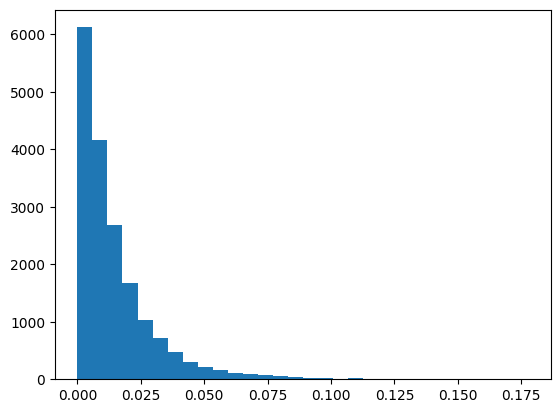

In [19]:
plt.hist(np.abs(r),bins=30)

In [100]:
def r_a(a):
    return " - ".join([f"{round(x,3):0.3f}" for x in a])
def show(error):
    for k in error:
        print(f"n_est {k[0]} m_depth {k[1]} => {r_a(error[k])}")

In [83]:
def check(params):
    error = {}
    for n_est in params["n_est"]:
        for m_depth in params["m_depth"]:
            param={"n_est":n_est,"m_depth":m_depth}
            model,e = train_model(train_df, model_X_cols, n_mimo,param=param, save_model=save_model, save_model_folder=save_model_folder)
            rmse_error_train,thresh_error_train,rmae_error,r2_score = test_model(model, test_df, model_X_cols, n_mimo)
            error[(n_est,m_depth)] = (rmse_error_train,thresh_error_train,rmae_error,r2_score)+e
            print(f"n_est {n_est} m_depth {m_depth} => {r_a(error[(n_est,m_depth)])}")
    return error

In [84]:
params={"n_est":[1000],"m_depth":[4],"learning_rate":0.1}
error = check(params)
show(error)

2025-09-29 16:33:03 - train_model - INFO - Model has been trained successfully


n_est 1000 m_depth 4 => 2.579 - 56.419 - 1.717 - 0.992 - 1.832 - 46.635 - 1.238 - 0.996
n_est 1000 m_depth 4 => 2.579 - 56.419 - 1.717 - 0.992 - 1.832 - 46.635 - 1.238 - 0.996


In [53]:
params={"n_est":range(10,50,10),"m_depth":range(10,50,5)}
error = check(params)
show(error)

2025-09-29 11:28:47 - train_model - INFO - Model has been trained successfully


n_est 10 m_depth 10 => 4.076 - 67.095 - 2.712 - 0.979 - 3.718 - 62.456 - 2.375 - 0.984


2025-09-29 11:29:11 - train_model - INFO - Model has been trained successfully


n_est 10 m_depth 15 => 2.935 - 56.347 - 1.882 - 0.989 - 1.951 - 37.359 - 1.198 - 0.995


2025-09-29 11:29:40 - train_model - INFO - Model has been trained successfully


...

n_est 40 m_depth 35 => 2.675 - 51.693 - 1.672 - 0.991 - 0.908 - 10.768 - 0.497 - 0.999


2025-09-29 11:58:01 - train_model - INFO - Model has been trained successfully


n_est 40 m_depth 40 => 2.672 - 51.454 - 1.670 - 0.991 - 0.908 - 10.759 - 0.497 - 0.999


2025-09-29 11:59:46 - train_model - INFO - Model has been trained successfully


n_est 40 m_depth 45 => 2.672 - 51.510 - 1.670 - 0.991 - 0.908 - 10.765 - 0.497 - 0.999
n_est 10 m_depth 10 => 4.076 - 67.095 - 2.712 - 0.979 - 3.718 - 62.456 - 2.375 - 0.984
n_est 10 m_depth 15 => 2.935 - 56.347 - 1.882 - 0.989 - 1.951 - 37.359 - 1.198 - 0.995
n_est 10 m_depth 20 => 2.792 - 53.654 - 1.751 - 0.990 - 1.285 - 20.449 - 0.731 - 0.998
n_est 10 m_depth 25 => 2.777 - 53.006 - 1.735 - 0.990 - 1.056 - 13.988 - 0.569 - 0.999
n_est 10 m_depth 30 => 2.749 - 53.000 - 1.729 - 0.990 - 1.030 - 12.690 - 0.539 - 0.999
n_est 10 m_depth 35 => 2.754 - 52.751 - 1.724 - 0.990 - 1.026 - 12.737 - 0.537 - 0.999
n_est 10 m_depth 40 => 2.772 - 52.546 - 1.724 - 0.990 - 1.031 - 12.687 - 0.538 - 0.999
n_est 10 m_depth 45 => 2.764 - 52.751 - 1.725 - 0.990 - 1.030 - 12.723 - 0.538 - 0.999
n_est 20 m_depth 10 => 4.062 - 66.929 - 2.709 - 0.979 - 3.712 - 62.546 - 2.382 - 0.984
n_est 20 m_depth 15 => 2.898 - 56.241 - 1.867 - 0.989 - 1.908 - 37.373 - 1.187 - 0.996
n_est 20 m_depth 20 => 2.752 - 53.216 - 1.7

In [35]:
params={"n_est":[10],"m_depth":[10,11,12,13,14,15]}
error = check(params)
show(error)

2025-09-29 11:07:44 - train_model - INFO - Model has been trained successfully
2025-09-29 11:08:03 - train_model - INFO - Model has been trained successfully
2025-09-29 11:08:21 - train_model - INFO - Model has been trained successfully
2025-09-29 11:08:42 - train_model - INFO - Model has been trained successfully
2025-09-29 11:09:03 - train_model - INFO - Model has been trained successfully
2025-09-29 11:09:25 - train_model - INFO - Model has been trained successfully


n_est 10 m_depth 10 => 3.718 - 62.456 - 2.375 - 0.984
n_est 10 m_depth 11 => 3.319 - 58.614 - 2.121 - 0.987
n_est 10 m_depth 12 => 2.859 - 53.514 - 1.830 - 0.990
n_est 10 m_depth 13 => 2.468 - 48.251 - 1.574 - 0.993
n_est 10 m_depth 14 => 2.168 - 42.489 - 1.355 - 0.994
n_est 10 m_depth 15 => 1.951 - 37.359 - 1.198 - 0.995


In [36]:
params={"n_est":[10],"m_depth":[15,16,17,18,19,20]}
error = check(params)
show(error)

2025-09-29 11:10:35 - train_model - INFO - Model has been trained successfully
2025-09-29 11:10:59 - train_model - INFO - Model has been trained successfully
2025-09-29 11:11:24 - train_model - INFO - Model has been trained successfully
2025-09-29 11:11:50 - train_model - INFO - Model has been trained successfully
2025-09-29 11:12:17 - train_model - INFO - Model has been trained successfully
2025-09-29 11:12:44 - train_model - INFO - Model has been trained successfully


n_est 10 m_depth 15 => 1.951 - 37.359 - 1.198 - 0.995
n_est 10 m_depth 16 => 1.773 - 33.320 - 1.075 - 0.996
n_est 10 m_depth 17 => 1.617 - 29.369 - 0.968 - 0.997
n_est 10 m_depth 18 => 1.486 - 25.784 - 0.872 - 0.997
n_est 10 m_depth 19 => 1.386 - 22.959 - 0.797 - 0.998
n_est 10 m_depth 20 => 1.285 - 20.449 - 0.731 - 0.998


In [56]:
params={"n_est":[100],"m_depth":[50]}
error = check(params)
show(error)

2025-09-29 16:00:24 - train_model - INFO - Model has been trained successfully


n_est 100 m_depth 50 => 2.649 - 51.549 - 1.663 - 0.991 - 0.876 - 10.457 - 0.489 - 0.999
n_est 100 m_depth 50 => 2.649 - 51.549 - 1.663 - 0.991 - 0.876 - 10.457 - 0.489 - 0.999


In [ ]:
params={"n_est":[100],"m_depth":[50]}
error = check(params)
show(error)

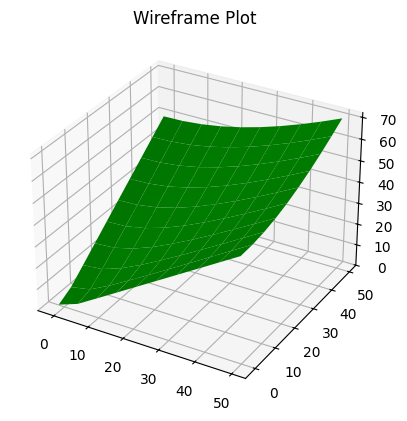

In [70]:
def f(x, y):
    return (np.sqrt(x**2 + y**2))

x = np.linspace(-1, 50, 10)
y = np.linspace(-1, 50, 10)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

fig = plt.figure()
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, Z, color='green')
ax.set_title('Wireframe Plot')
plt.show()

In [290]:
d1 = np.datetime64("2024-10-02")
d2 = d1-np.timedelta64(7,'D')
dates  = df["date"]
masknamecode=(df["name"] == "پرند")&(df["code"] == "G11")
dff = df[masknamecode]
dfff = dff[(np.datetime64(d1)>=pd.to_datetime(dff["date"]))&(np.datetime64(d2)<=pd.to_datetime(dff["date"]))]
p = dfff["generation"].mean()
e = dff[(np.datetime64(d1)==pd.to_datetime(dff["date"]))]["generation"]
(np.abs(e-p)/p).max()

0.14285306231190384

0.14285306231190384